In [1]:
%cd Negation

/home/amirhossein.hajimohammadrezaie/ECOR_extended/Negation


In [3]:
import clip
import torch
import numpy as np
import pandas as pd
import ast
from transformers import CLIPTokenizer
from torch.utils.data import Dataset, DataLoader, default_collate
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from video_utils.frame_sampler import UniformFrameSampler
from video_utils.video_reader import VideoReader
import torch.nn.functional as F
from transformers import AutoModelForCausalLM
import torch.nn as nn
import seaborn as sns
import os

In [4]:
class NegationEmbedding(nn.Module):
    def __init__(self, embedding_size=512, intializer: torch.Tensor = None):
        super(NegationEmbedding, self).__init__()
        
        self.embedding = nn.Parameter(torch.zeros(1, embedding_size))

        if intializer is not None:
            self.embedding.data = intializer
        else:
            nn.init.normal_(self.embedding, std=0.02)

    def forward(self):
        return self.embedding

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)
preprocess = transforms.Compose([transforms.Resize((224, 224), transforms.InterpolationMode.BICUBIC, antialias=True)] + preprocess.transforms)
model.eval()
model = model.to(torch.float32)
batch_size = 128

for param in model.parameters():
    param.requires_grad = False

In [ ]:
neg_embedding = NegationEmbedding()
neg_embedding = neg_embedding.to(device)

save_file = torch.load("save/neg_embedv5.pth")
neg_embedding.load_state_dict(save_file['neg_embed_state_dict'])
print("Epoch: ", save_file['epoch'], ", Loss: ", save_file['loss'])

Epoch:  9 , Loss:  0.00021973434244067114


In [7]:
@torch.no_grad()
def negate(texts, neg_embedding):
    tokens = clip.tokenize(texts).to(device)
    x = model.token_embedding(tokens)
    x = torch.cat([x[:,[0],:], neg_embedding.expand(x.shape[0], -1, -1), x[:, 1:-1,:]], dim=-2)

    x = x + model.positional_embedding.type(model.dtype)
    x = x.permute(1, 0, 2)
    x = model.transformer(x)
    x = x.permute(1, 0, 2)
    x = model.ln_final(x).type(model.dtype)
    neg_word_embedding = x[torch.arange(x.shape[0]), tokens.argmax(dim=-1)+1] @ model.text_projection

    return neg_word_embedding

In [10]:
aff_embed = model.encode_text(clip.tokenize("prior").to(device)).detach()
aff_embed = F.normalize(aff_embed, dim=-1)

vanilla_neg_embed = model.encode_text(clip.tokenize("not prior").to(device)).detach()
vanilla_neg_embed = F.normalize(vanilla_neg_embed, dim=-1)

neg_embed = negate("prior", neg_embedding())
neg_embed = F.normalize(neg_embed, dim=-1)

target_embed = model.encode_text(clip.tokenize("posterior").to(device)).detach()
target_embed = F.normalize(target_embed, dim=-1)

In [43]:
print(f"negated('prior') & 'posterior' : {torch.squeeze(neg_embed @ target_embed.t()).item():.4f}")
print(f"'not prior' & 'posterior' : {torch.squeeze(vanilla_neg_embed @ target_embed.t()).item():.4f}")


negated('prior') & 'posterior' : 0.7919
'not prior' & 'posterior' : 0.7631


## Dataset

In [ ]:
#tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
#tokenizer.convert_tokens_to_ids("<not>")

In [49]:
class CsvImageCaptionDataset(Dataset):
    def __init__(self, csv_file, transforms, sep=',', img_key='filepath', caption_key='captions'):
        
        self.df = pd.read_csv(csv_file, sep=sep)
        
        self.df['negated_captions'] = self.df.apply(lambda row: [cap + f" but there is not {neg_obj}" for cap in eval(row['captions']) for neg_obj in eval(row['negative_objects'])], axis=1)
        self.df['captions'] = self.df['captions'].apply(lambda caps: [cap for cap in eval(caps)])

        self.transforms = transforms
        self.img_key = img_key
        self.caption_key = caption_key

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx][self.img_key]
        images = self.transforms(Image.open(image_path))
        captions = self.df.iloc[idx][self.caption_key]
        return images, captions

dataset = CsvImageCaptionDataset(csv_file='data/images/COCO_val_negated_retrieval_llama3.1_rephrased_affneg_true.csv', transforms=preprocess, img_key='filepath', caption_key='captions')

In [54]:
class CsvVideoCaptionDataset(Dataset):
    def __init__(self, csv_file, transforms, sep=',', img_key='filepath', caption_key='captions'):
        
        self.df = pd.read_csv(csv_file, sep=sep)
        
        self.df['captions'] = self.df['captions'].apply(lambda caps: eval(caps))
        self.df['negated_captions'] = self.df.apply(lambda row: [row['captions'][0] + f" but there is not {row['negative_concept']}"], axis=1)

        self.transforms = transforms
        self.img_key = img_key
        self.caption_key = caption_key

        self.all_frames = []
        self.create_data()


    def create_data(self):
        for video_path in tqdm(self.df['image_id'], total=len(self.df), desc="Extracting frames ..."):
            video_path = "data/msr-vtt/TestVideo/" + video_path + ".mp4"
            self.all_frames.append(self.sample_frames(video_path))


    def sample_frames(self, video_path, num_frames=4):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames == 0:
            raise ValueError("Video has no frames or cannot be read.")

        # Compute frame indices to sample
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

        sampled_images = []
        for frame_idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            success, frame = cap.read()
            if not success:
                continue
            # Convert BGR (OpenCV) to RGB (PIL)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)
            sampled_images.append(pil_img)

        cap.release()
        return sampled_images

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        frames = self.all_frames[idx]
        transformed_frames = []
        for frame in frames:
            transformed_frames.append(self.transforms(frame))
        
        transformed_frames = torch.stack(transformed_frames, dim=0)
        captions = self.df.iloc[idx][self.caption_key]
        
        return transformed_frames, captions

dataset = CsvVideoCaptionDataset(csv_file='data/videos/msr_vtt_retrieval_rephrased_llama.csv', transforms=preprocess, img_key='filepath', caption_key='captions')

Extracting frames ...:   0%|          | 4/1000 [00:00<00:30, 32.53it/s]

Extracting frames ...: 100%|██████████| 1000/1000 [00:39<00:00, 25.25it/s]


In [55]:
def image_captions_collate_fn(batch):
    images, texts = list(zip(*batch))
    images = default_collate(images)
    return images, texts

def dataloader_with_indices(dataloader):
    start = 0
    for x, y in dataloader:
        end = start + len(x)
        inds = torch.arange(start, end)
        yield x, y, inds
        start = end

dataLoader = DataLoader(dataset, batch_size, collate_fn=image_captions_collate_fn, shuffle=False)
len_dataLoader = len(dataLoader)
dataLoader = dataloader_with_indices(dataLoader)

In [56]:
def batchify(func, X, Y, batch_size, device, *args, **kwargs):
    results = []
    for start in range(0, len(X), batch_size):
        end = start + batch_size
        x = X[start:end].to(device)
        y = Y[start:end].to(device)
        result = func(x, y, *args, **kwargs).cpu()
        results.append(result)
    return torch.cat(results)

def recall_at_k(scores, positive_pairs, k):
    nb_texts, nb_images = scores.shape
    topk_indices = torch.topk(scores, k, dim=1)[1]
    nb_positive = positive_pairs.sum(dim=1)
    topk_indices_onehot = torch.nn.functional.one_hot(topk_indices, num_classes=nb_images)
    positive_pairs_reshaped = positive_pairs.view(nb_texts, 1, nb_images)
    nb_true_positive = (topk_indices_onehot * positive_pairs_reshaped).sum(dim=(1,2))
    recall_at_k = (nb_true_positive / nb_positive)
    return recall_at_k

## MCQ Evaluation

In [91]:
df = pd.read_csv("data/videos/msr_vtt_mcq_templated.csv")
df

,correct_answer,caption_0,caption_1,caption_2,caption_3,correct_answer_template,image_path
0,1,"This video features marching, but not pokemon",This video features dancing and pokemon,This video does not feature dancing,This video features marching,positive,/data/healthy-ml/scratch/kumail/projects/cs/ne...
1,0,This video features working and technology,This video does not feature working,"This video features arguing, but not technology",This video features arguing,positive,/data/healthy-ml/scratch/kumail/projects/cs/ne...
2,0,"This video features talking, but not fire","This video features fire, but not talking",This video does not feature woman,This video features fire,hybrid,/data/healthy-ml/scratch/kumail/projects/cs/ne...
3,1,This video does not feature animation,"This video features cabinet, but not person","This video features person, but not cabinet",This video features person,hybrid,/data/healthy-ml/scratch/kumail/projects/cs/ne...
4,3,This video features painting,This video does not feature craft,"This video features painting, but not creating",This video features craft and creating,positive,/data/healthy-ml/scratch/kumail/projects/cs/ne...
...,...,...,...,...,...,...,...
995,0,This video features dj and car,This video features fighting,"This video features fighting, but not car",This video does not feature dj,positive,/data/healthy-ml/scratch/kumail/projects/cs/ne...
996,0,This video does not feature bicycle,This video does not feature car,"This video features bicycle, but not driving",This video features bicycle,negative,/data/healthy-ml/scratch/kumail/projects/cs/ne...
997,3,This video does not feature cooking,This video features salad,"This video features salad, but not duck",This video features cooking and duck,positive,/data/healthy-ml/scratch/kumail/projects/cs/ne...
998,1,"This video features grilling, but not lasagna",This video does not feature grilling,This video features grilling,This video does not feature cooking,negative,/data/healthy-ml/scratch/kumail/projects/cs/ne...


In [92]:
def process_caption(s: str):
    aff = ""
    neg = ""

    if " not " in s:
        neg_cand = s.split(" not ")[1]
        neg_before = s.split(" not ")[0]
        
        if " does " in neg_before:
            try:
                neg = neg_cand.split("does not feature ")[1]
            except:
                print(s)
                raise Exception("Erro ... ")
        else:
            neg = neg_cand

    
    if " does not " not in s:
        if " but " in s:
            aff_cand = s.split(" but ")[0]
            aff = aff_cand.split(" features ")[1]
        else:
            try:
                aff = s.split(" features ")[1]
            except:
                Exception("Error last ....")
 

    return aff, neg

In [93]:
df['caption_0'] = df['caption_0'].apply(process_caption)
df['caption_1'] = df['caption_1'].apply(process_caption)
df['caption_2'] = df['caption_2'].apply(process_caption)
df['caption_3'] = df['caption_3'].apply(process_caption)

In [107]:
df['image_path'] = df['image_path'].apply(lambda s: os.path.basename(s))
df.to_csv("data/images/msr_vtt_mcq_splitted.csv")

In [29]:
class MCQDataset(Dataset):
    def __init__(self, file_path, transforms):
        super(MCQDataset, self).__init__()
        
        self.df = pd.read_csv(file_path)
        self.transform = transforms
        
    def __getitem__(self, index):
        image = self.transform(Image.open(self.df.iloc[index]['image_path']))
        caption_0 = self.df.iloc[index]['caption_0']
        caption_1 = self.df.iloc[index]['caption_1']
        caption_2 = self.df.iloc[index]['caption_2']
        caption_3 = self.df.iloc[index]['caption_3']
        label = self.df.iloc[index]['correct_answer']
        template = self.df.iloc[index]['correct_answer_template']
        
        return image, caption_0, caption_1, caption_2, caption_3, label, template
        
    def __len__(self):
        return len(self.df)
    
    
dataset = MCQDataset(file_path='data/images/VOC2007_mcq_llama3.1_rephrased.csv', transforms=preprocess)   
dataLoader = DataLoader(dataset, batch_size=batch_size, shuffle=False) 

In [59]:
class MCQDatasetV2(Dataset):
    def __init__(self, file_path, transforms):
        super(MCQDatasetV2, self).__init__()
        
        self.df = pd.read_csv(file_path)
        self.df['caption_0'] = self.df['caption_0'].apply(lambda x: eval(x))
        self.df['caption_1'] = self.df['caption_1'].apply(lambda x: eval(x))
        self.df['caption_2'] = self.df['caption_2'].apply(lambda x: eval(x))
        self.df['caption_3'] = self.df['caption_3'].apply(lambda x: eval(x))
        self.transform = transforms
    
    def check_neg_caption_format(self, caption):
        if caption.startswith('No'):
            caption = caption.split('No')[1].strip()
            
        elif caption == "":
            pass
        
        else:
            raise Exception(f"index {caption}: {caption} -- Format is incorrect!") 
        
        return caption
        
        
    def __getitem__(self, index):
        image = self.transform(Image.open(self.df.iloc[index]['image_path']))
        caption_0_pos, caption_0_neg = self.df.iloc[index]['caption_0']
        caption_1_pos, caption_1_neg = self.df.iloc[index]['caption_1']
        caption_2_pos, caption_2_neg = self.df.iloc[index]['caption_2']
        caption_3_pos, caption_3_neg = self.df.iloc[index]['caption_3']
        
        caption_0_neg = self.check_neg_caption_format(caption_0_neg)
        caption_1_neg = self.check_neg_caption_format(caption_1_neg)
        caption_2_neg = self.check_neg_caption_format(caption_2_neg)
        caption_3_neg = self.check_neg_caption_format(caption_3_neg)
        
        label = self.df.iloc[index]['correct_answer']
        template = self.df.iloc[index]['correct_answer_template']
        
        return image, caption_0_pos, caption_0_neg, caption_1_pos, caption_1_neg, caption_2_pos, caption_2_neg,\
                caption_3_pos, caption_3_neg, label, template
        
    def __len__(self):
        return len(self.df)
    
    
dataset = MCQDatasetV2(file_path='data/images/COCO_val_mcq_splitted_rephrased.csv', transforms=preprocess)   
dataLoader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class MCQDatasetV3(Dataset):
    def __init__(self, file_path, transforms):
        super(MCQDatasetV3, self).__init__()
        
        self.df = pd.read_csv(file_path)
        self.df['caption_0'] = self.df['caption_0'].apply(lambda x: eval(x))
        self.df['caption_1'] = self.df['caption_1'].apply(lambda x: eval(x))
        self.df['caption_2'] = self.df['caption_2'].apply(lambda x: eval(x))
        self.df['caption_3'] = self.df['caption_3'].apply(lambda x: eval(x))
        self.transform = transforms
    
    def check_neg_caption_format(self, caption):
        if caption.startswith('No'):
            caption = caption.split('No')[1].strip()
            
        elif caption == "":
            pass
        
        else:
            raise Exception(f"index {caption}: {caption} -- Format is incorrect!") 
        
        return caption
        
        
    def __getitem__(self, index):
        image = self.transform(Image.open(self.df.iloc[index]['image_path']))
        caption_0_pos, caption_0_neg = self.df.iloc[index]['caption_0']
        caption_1_pos, caption_1_neg = self.df.iloc[index]['caption_1']
        caption_2_pos, caption_2_neg = self.df.iloc[index]['caption_2']
        caption_3_pos, caption_3_neg = self.df.iloc[index]['caption_3']
        
        caption_0_pos = "A photo of a " + caption_0_pos if caption_0_pos != "" else "This is a photo"
        caption_1_pos = "A photo of a " + caption_1_pos if caption_1_pos != "" else "This is a photo"
        caption_2_pos = "A photo of a " + caption_2_pos if caption_2_pos != "" else "This is a photo"
        caption_3_pos = "A photo of a " + caption_3_pos if caption_3_pos != "" else "This is a photo"

        caption_0_neg = "Not "
        
        label = self.df.iloc[index]['correct_answer']
        template = self.df.iloc[index]['correct_answer_template']
        
        return image, caption_0_pos, caption_0_neg, caption_1_pos, caption_1_neg, caption_2_pos, caption_2_neg,\
                caption_3_pos, caption_3_neg, label, template
        
    def __len__(self):
        return len(self.df)
    
    
dataset = MCQDatasetV3(file_path='data/images/COCO_val_mcq_splitted_rephrased.csv', transforms=preprocess)   
dataLoader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [116]:
class MCQVideoDataset(Dataset):
    def __init__(self, file_path, transforms):
        super(MCQVideoDataset, self).__init__()
        
        self.df = pd.read_csv(file_path)
        self.transforms = transforms
        self.all_frames = []
        self.create_data()


    def create_data(self):
        for video_path in tqdm(self.df['image_path'], total=len(self.df), desc="Extracting frames ..."):
            video_path = "data/msr-vtt/TestVideo/" + video_path
            self.all_frames.append(self.sample_frames(video_path))


    def sample_frames(self, video_path, num_frames=4):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames == 0:
            raise ValueError("Video has no frames or cannot be read.")

        # Compute frame indices to sample
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

        sampled_images = []
        for frame_idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            success, frame = cap.read()
            if not success:
                continue
            # Convert BGR (OpenCV) to RGB (PIL)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(frame_rgb)
            sampled_images.append(pil_img)

        cap.release()
        return sampled_images
    
    def __getitem__(self, index):
        frames = self.all_frames[index]
        transformed_frames = []
        for frame in frames:
            transformed_frames.append(self.transforms(frame))
        
        transformed_frames = torch.stack(transformed_frames, dim=0)

        caption_0 = self.df.iloc[index]['caption_0']
        caption_1 = self.df.iloc[index]['caption_1']
        caption_2 = self.df.iloc[index]['caption_2']
        caption_3 = self.df.iloc[index]['caption_3']
        label = self.df.iloc[index]['correct_answer']
        template = self.df.iloc[index]['correct_answer_template']
        
        return transformed_frames, caption_0, caption_1, caption_2, caption_3, label, template
        
    def __len__(self):
        return len(self.df)
    
    
dataset = MCQVideoDataset(file_path='data/videos/msr_vtt_mcq_rephrased_llama.csv', transforms=preprocess)   
dataLoader = DataLoader(dataset, batch_size=batch_size, shuffle=False) 

Extracting frames ...:   2%|▏         | 18/1000 [00:00<00:36, 27.14it/s]

Extracting frames ...: 100%|██████████| 1000/1000 [00:38<00:00, 26.15it/s]


In [118]:
image, caption_0, caption_1, caption_2, caption_3, label, template = next(iter(dataLoader))

In [127]:
@torch.no_grad()
def evaluation(model, dataLoader, device) :
    accs = []
    templates = []
    
    for image, caption_0, caption_1, caption_2, caption_3, label, template in tqdm(dataLoader, total=len(dataLoader)):
        image = image.to(device)
        
        caption_0 = clip.tokenize(caption_0).to(device)
        caption_1 = clip.tokenize(caption_1).to(device)
        caption_2 = clip.tokenize(caption_2).to(device)
        caption_3 = clip.tokenize(caption_3).to(device)
        label = label.to(device)

        caption_0_embed = F.normalize(model.encode_text(caption_0), dim=-1) # B x d
        caption_1_embed = F.normalize(model.encode_text(caption_1), dim=-1) # B x d
        caption_2_embed = F.normalize(model.encode_text(caption_2), dim=-1) # B x d
        caption_3_embed = F.normalize(model.encode_text(caption_3), dim=-1) # B x d
        captions_embed = torch.stack([caption_0_embed, caption_1_embed, caption_2_embed, caption_3_embed], dim=1) # B x 4 x d
        
        #image_embed = F.normalize(model.encode_image(image), dim=-1) # B x d
        image_embed = F.normalize(model.encode_image(image.reshape((-1, *image.shape[2:]))), dim=-1)
        image_embed = image_embed.reshape((image.shape[0], image.shape[1], image_embed.shape[-1]))
        image_embed = image_embed.mean(dim=1)
        
        scores = torch.squeeze(image_embed[:, None, :] @ captions_embed.permute((0,2,1)), dim=-2) # B x 4
        preds = torch.argmax(scores, dim=-1) # (B,)
        accs.append((preds == label).float().cpu().numpy())
        templates.extend(template)
        
    accs = np.concatenate(accs, axis=0)
    templates = np.array(templates)

    accs_per_template = {}
    
    for acc, template in zip(accs, templates):
        if template not in accs_per_template:
            accs_per_template[template] = []
            
        accs_per_template[template].append(acc)
    
    accs_per_template = {k: np.mean(v) for k, v in accs_per_template.items()}
    print(" Accuracies: ", accs_per_template)
    print(" Mean Accuracy: ", np.mean(accs))

In [128]:
evaluation(model, dataLoader, device)

100%|██████████| 8/8 [00:08<00:00,  1.10s/it]

 Accuracies:  {'positive': 0.6089552, 'negative': 0.15580736, 'hybrid': 0.1826923}
 Mean Accuracy:  0.316


In [55]:
evaluation(model, dataLoader, device)

100%|██████████| 45/45 [00:55<00:00,  1.24s/it]

 Accuracies:  {'hybrid': 0.3799082, 'negative': 0.11771238, 'positive': 0.6624171}
 Mean Accuracy:  0.39419883


## Retreival Evaluation

In [ ]:
not_idx = 783
model.token_embedding.weight.data[[not_idx]] = neg_embedding().data

In [69]:
@torch.no_grad()
def text_encoder(model, toks, not_embed=None, not_mask=False):
    x = model.token_embedding(toks).type(model.dtype)
    rows, cols = torch.where(toks == 783) # not_idx=783
    
    if not_embed is not None:
        for row, col in zip(rows, cols):
            x[row, [col], :] = not_embed
    
    x = x + model.positional_embedding.type(model.dtype)
    x = x.permute(1, 0, 2) 
    
    mask = torch.empty(toks.shape[0], model.context_length, model.context_length)
    mask.fill_(float("-inf"))
    mask.triu_(1)
    
    if not_mask:
        for row, col in zip(rows, cols):
            mask[row, col, col:] = 0.
            mask[row, col, :col] = float("-inf")
    
    mask = mask.repeat_interleave(model.transformer.resblocks[0].attn.num_heads, dim=0)
    mask = mask.to(dtype=x.dtype, device=x.device)
    
    
    for block in model.transformer.resblocks:
        y = block.ln_1(x)
        y = block.attn(y, y, y, need_weights=False, attn_mask=mask)[0]
        x = x + y
        y = block.mlp(block.ln_2(x))
        x = x + y
    
    x = x.permute(1, 0, 2)
    x = model.ln_final(x).type(model.dtype)
    x = x[torch.arange(x.shape[0]), toks.argmax(dim=-1)] @ model.text_projection
    
    texts_emb = F.normalize(x, dim=-1)
    
    return texts_emb


@torch.no_grad()
def retreival_evaluation(model, dataLoader, device):    
    batch_images_emb_list = []
    batch_texts_emb_list = []
    texts_image_index = []
    
    for batch_images, batch_texts, inds in tqdm(dataLoader, total=len_dataLoader):
        batch_images = batch_images.to(device)
        batch_texts_tok = clip.tokenize([text for i, texts in enumerate(batch_texts) for text in texts], truncate=True).to(device)
        batch_texts_image_index = [ind for ind, texts in zip(inds, batch_texts) for text in texts]

        # Compute image embeddings
        batch_images_emb = F.normalize(model.encode_image(batch_images), dim=-1)
        
        # Compute text embeddings
        batch_texts_emb = text_encoder(model, batch_texts_tok, not_embed=neg_embedding(), not_mask=True)
        
        # Append the embeddings and indices
        batch_images_emb_list.append(batch_images_emb.cpu())
        batch_texts_emb_list.append(batch_texts_emb.cpu())
        texts_image_index.extend(batch_texts_image_index)


    samples_num = len(batch_images_emb_list[0])
    images_emb = torch.cat(batch_images_emb_list, dim=0)
    texts_emb = torch.cat(batch_texts_emb_list, dim=0)

    # Compute the scores
    scores = texts_emb @ images_emb.t()
    positive_pairs = torch.zeros_like(scores, dtype=bool)
    positive_pairs[torch.arange(len(scores)), texts_image_index] = True
    
    # Compute the recall@k
    img_retrieval_5 = (batchify(recall_at_k, scores, positive_pairs, samples_num, device, k=5)>0).float().mean().item()
    txt_retrieval_5= (batchify(recall_at_k, scores.T, positive_pairs.T, samples_num, device, k=5)>0).float().mean().item()

    print(f"Image retrieval at 5: {img_retrieval_5:.2f}")
    print(f"Text retrieval at 5: {txt_retrieval_5:.2f}")

In [57]:
@torch.no_grad()
def retreival_evaluation(model, dataLoader, device):    
    batch_images_emb_list = []
    batch_texts_emb_list = []
    texts_image_index = []

    for batch_images, batch_texts, inds in tqdm(dataLoader, total=len_dataLoader):
        batch_images = batch_images.to(device)
        batch_texts_tok = clip.tokenize([text for i, texts in enumerate(batch_texts) for text in texts], truncate=True).to(device)
        batch_texts_image_index = [ind for ind, texts in zip(inds, batch_texts) for text in texts]

        # Compute the embeddings
        #batch_images_emb = F.normalize(model.encode_image(batch_images), dim=-1)
        
        
        batch_images_emb = F.normalize(model.encode_image(batch_images.reshape((-1, *batch_images.shape[2:]))), dim=-1)
        batch_images_emb = batch_images_emb.reshape((batch_images.shape[0], batch_images.shape[1], batch_images_emb.shape[-1]))
        batch_images_emb = batch_images_emb.mean(dim=1)
        
        
        batch_texts_emb = F.normalize(model.encode_text(batch_texts_tok), dim=-1)
        
        # Append the embeddings and indices
        batch_images_emb_list.append(batch_images_emb.cpu())
        batch_texts_emb_list.append(batch_texts_emb.cpu())
        texts_image_index.extend(batch_texts_image_index)


    samples_num = len(batch_images_emb_list[0])
    images_emb = torch.cat(batch_images_emb_list, dim=0)
    texts_emb = torch.cat(batch_texts_emb_list, dim=0)

    # Compute the scores
    scores = texts_emb @ images_emb.t()
    positive_pairs = torch.zeros_like(scores, dtype=bool)
    positive_pairs[torch.arange(len(scores)), texts_image_index] = True
    
    # Compute the recall@k
    img_retrieval_5 = (batchify(recall_at_k, scores, positive_pairs, samples_num, device, k=5)>0).float().mean().item()
    txt_retrieval_5= (batchify(recall_at_k, scores.T, positive_pairs.T, samples_num, device, k=5)>0).float().mean().item()

    print(f"Image retrieval at 5: {img_retrieval_5:.3g}")
    print(f"Text retrieval at 5: {txt_retrieval_5:.3g}")

In [40]:
retreival_evaluation(model, dataLoader, device)

100%|██████████| 40/40 [00:41<00:00,  1.03s/it]


Image retrieval at 5: 0.547
Text retrieval at 5: 0.741


In [53]:
retreival_evaluation(model, dataLoader, device)

100%|██████████| 40/40 [01:05<00:00,  1.64s/it]


Image retrieval at 5: 0.479
Text retrieval at 5: 0.691


In [58]:
retreival_evaluation(model, dataLoader, device)

100%|██████████| 8/8 [00:07<00:00,  1.06it/s]

Image retrieval at 5: 0.459
Text retrieval at 5: 0.384


In [163]:
retreival_evaluation(model, dataLoader, device)

100%|██████████| 40/40 [01:20<00:00,  2.01s/it]


Image retrieval at 5: 0.51
Text retrieval at 5: 0.64


In [10]:
retreival_evaluation(model, dataLoader, device)

100%|██████████| 40/40 [01:16<00:00,  1.90s/it]


Image retrieval at 5: 0.51
Text retrieval at 5: 0.65


In [70]:
retreival_evaluation(model, dataLoader, device)

100%|██████████| 40/40 [01:30<00:00,  2.27s/it]


Image retrieval at 5: 0.51
Text retrieval at 5: 0.63


## Training

In [ ]:
"""
class NegationDataset(Dataset):
    def __init__(self, csv_file, clip_model):
        super(NegationDataset).__init__()

        self.df = pd.read_csv(csv_file, sep=',')
        self.clip_model = clip_model
        self.positive_embeddings = []
        self.negative_embeddings = []
        self.not_embeddings = []

        self.compute_embeddings()

    def compute_embeddings(self):
        with torch.no_grad():
            for i, row in tqdm(self.df.iterrows(), total=len(self.df)):
                word1 = clip.tokenize(row['Word']).to(device)
                word1_emb = model.encode_text(word1)
                word1_emb = F.normalize(word1_emb, dim=-1)
                self.positive_embeddings.append(word1_emb)

                word2 = clip.tokenize(row['Antonyms']).to(device)
                word2_emb = model.encode_text(word2)
                word2_emb = F.normalize(word2_emb, dim=-1)
                self.negative_embeddings.append(word2_emb)

                not_word = clip.tokenize("not " + row['Word']).to(device)
                not_word_emb = model.encode_text(not_word)
                not_word_emb = F.normalize(not_word_emb, dim=-1)
                self.not_embeddings.append(not_word_emb)
            

    def __getitem__(self, index):
        word1 = self.df.iloc[index]['Word']
        word1_embed = self.positive_embeddings[index]
        word2_embed = self.negative_embeddings[index]
        not_word_embed = self.not_embeddings[index]        

        return word1, word1_embed, word2_embed, not_word_embed
    
    def __len__(self):
        return len(self.df)    
    
"""    

class NegationDataset(Dataset):
    def __init__(self, csv_file, clip_model):
        super(NegationDataset).__init__()

        self.df = pd.read_csv(csv_file, sep=',')
        self.clip_model = clip_model
        self.positive_embeddings = []
        self.negative_embeddings = []
        self.not_embeddings = []

        self.compute_embeddings()

    def compute_embeddings(self):
        with torch.no_grad():
            for i, row in tqdm(self.df.iterrows(), total=len(self.df)):
                #--------------------------------------------------------
                word1 = clip.tokenize(row['Word']).to(device)
                word1_emb = model.encode_text(word1)
                word1_emb = F.normalize(word1_emb, dim=-1)
                self.positive_embeddings.append(word1_emb)

                word2 = clip.tokenize(row['Antonyms']).to(device)
                word2_emb = model.encode_text(word2)
                word2_emb = F.normalize(word2_emb, dim=-1)
                self.negative_embeddings.append(word2_emb)

                not_word = clip.tokenize("not " + row['Word']).to(device)
                not_word_emb = model.encode_text(not_word)
                not_word_emb = F.normalize(not_word_emb, dim=-1)
                self.not_embeddings.append(not_word_emb)

                #--------------------------------------------------------
                word1 = clip.tokenize("a photo of " + row['Word']).to(device)
                word1_emb = model.encode_text(word1)
                word1_emb = F.normalize(word1_emb, dim=-1)
                self.positive_embeddings.append(word1_emb)

                word2 = clip.tokenize("a photo of " + row['Antonyms']).to(device)
                word2_emb = model.encode_text(word2)
                word2_emb = F.normalize(word2_emb, dim=-1)
                self.negative_embeddings.append(word2_emb)

                not_word = clip.tokenize("not a photo of " + row['Word']).to(device)
                not_word_emb = model.encode_text(not_word)
                not_word_emb = F.normalize(not_word_emb, dim=-1)
                self.not_embeddings.append(not_word_emb)

                #--------------------------------------------------------
                word1 = clip.tokenize("there is " + row['Word']).to(device)
                word1_emb = model.encode_text(word1)
                word1_emb = F.normalize(word1_emb, dim=-1)
                self.positive_embeddings.append(word1_emb)

                word2 = clip.tokenize("there is " + row['Antonyms']).to(device)
                word2_emb = model.encode_text(word2)
                word2_emb = F.normalize(word2_emb, dim=-1)
                self.negative_embeddings.append(word2_emb)

                not_word = clip.tokenize("there is not " + row['Word']).to(device)
                not_word_emb = model.encode_text(not_word)
                not_word_emb = F.normalize(not_word_emb, dim=-1)
                self.not_embeddings.append(not_word_emb)

                #--------------------------------------------------------
                word1 = clip.tokenize("this is a photo of " + row['Word']).to(device)
                word1_emb = model.encode_text(word1)
                word1_emb = F.normalize(word1_emb, dim=-1)
                self.positive_embeddings.append(word1_emb)

                word2 = clip.tokenize("this is a photo of " + row['Antonyms']).to(device)
                word2_emb = model.encode_text(word2)
                word2_emb = F.normalize(word2_emb, dim=-1)
                self.negative_embeddings.append(word2_emb)

                not_word = clip.tokenize("this is not a photo of " + row['Word']).to(device)
                not_word_emb = model.encode_text(not_word)
                not_word_emb = F.normalize(not_word_emb, dim=-1)
                self.not_embeddings.append(not_word_emb)
            

    def __getitem__(self, index):
        word1 = self.df.iloc[index//4]['Word']
        word1_embed = self.positive_embeddings[index]
        word2_embed = self.negative_embeddings[index]
        #not_word_embed = self.not_embeddings[index]        

        return word1, index % 4, word1_embed, word2_embed#, not_word_embed
    
    def __len__(self):
        return len(self.positive_embeddings)

In [37]:
class NegationDataset(Dataset):
    def __init__(self, csv_file, clip_model):
        super(NegationDataset).__init__()

        self.df = pd.read_csv(csv_file, sep=',')
        self.clip_model = clip_model
        self.positive_words = []
        self.negative_words = []
        self.not_words = []

        self.compute_embeddings()

    def compute_embeddings(self):
        with torch.no_grad():
            for i, row in tqdm(self.df.iterrows(), total=len(self.df)):
                #--------------------------------------------------------
                word1 = clip.tokenize("a " + row['Word']).squeeze(dim=0)
                self.positive_words.append(word1)

                word2 = clip.tokenize("a " + row['Antonyms']).squeeze(dim=0)
                self.negative_words.append(word2)

                not_word = clip.tokenize("not a " + row['Word']).squeeze(dim=0)
                self.not_words.append(not_word)

                #--------------------------------------------------------
                word1 = clip.tokenize("a photo of a " + row['Word']).squeeze(dim=0)
                self.positive_words.append(word1)

                word2 = clip.tokenize("a photo of a " + row['Antonyms']).squeeze(dim=0)
                self.negative_words.append(word2)

                not_word = clip.tokenize("not a photo of a " + row['Word']).squeeze(dim=0)
                self.not_words.append(not_word)

                #--------------------------------------------------------
                word1 = clip.tokenize("there is a " + row['Word']).squeeze(dim=0)
                self.positive_words.append(word1)

                word2 = clip.tokenize("there is a " + row['Antonyms']).squeeze(dim=0)
                self.negative_words.append(word2)

                not_word = clip.tokenize("there is not a " + row['Word']).squeeze(dim=0)
                self.not_words.append(not_word)

                #--------------------------------------------------------
                word1 = clip.tokenize("this is a photo of a " + row['Word']).squeeze(dim=0)
                self.positive_words.append(word1)

                word2 = clip.tokenize("this is a photo of a " + row['Antonyms']).squeeze(dim=0)
                self.negative_words.append(word2)

                not_word = clip.tokenize("this is not a photo of a " + row['Word']).squeeze(dim=0)
                self.not_words.append(not_word)
            

    def __getitem__(self, index):
        pos_word = self.positive_words[index]
        neg_word = self.negative_words[index]
        not_word = self.not_words[index]       

        return pos_word, neg_word, not_word
    
    def __len__(self):
        return len(self.positive_words)

In [38]:
trainset = NegationDataset(csv_file='WordnetAntonyms.csv', clip_model=model)
trainloader = DataLoader(trainset, batch_size, shuffle=True)

  1%|          | 114/11240 [00:00<00:19, 583.11it/s]

100%|██████████| 11240/11240 [00:17<00:00, 655.12it/s]


In [31]:
with torch.no_grad():

    criterion = nn.MSELoss()
    sim_neg_target = []
    sim_not_target = []
    sim_pos_target = []
    sim_pos_neg = []
    sim_pos_not = []
    sim_neg_not = []
    
    for i, (word1, word1_embed, word2_embed, not_embed) in tqdm(enumerate(trainloader), total=len(trainloader)):

        word1_embed = word1_embed.squeeze(dim=1).to(device)
        word2_embed = word2_embed.squeeze(dim=1).to(device)
        not_embed = not_embed.squeeze(dim=1).to(device)
        
        word1_tokens = clip.tokenize(word1).to(device)
        x = model.token_embedding(clip.tokenize(word1).to(device))
        x = torch.cat([x[:,[0],:], neg_embedding().expand(x.shape[0], -1, -1), x[:, 1:-1,:]], dim=-2)
        #x = torch.cat([x[:,0:3,:], neg_embedding().expand(x.shape[0], -1, -1), x[:, 3:-1,:]], dim=-2)
        ################################################### Copied From CLIP code
        x = x + model.positional_embedding.type(model.dtype)
        x = x.permute(1, 0, 2)
        x = model.transformer(x)
        x = x.permute(1, 0, 2)
        x = model.ln_final(x).type(model.dtype)
        neg_word_embedding = x[torch.arange(x.shape[0]), word1_tokens.argmax(dim=-1)+1] @ model.text_projection
        neg_word_embedding = F.normalize(neg_word_embedding)
        ###################################################


        # Compute the simmilarities
        sim_neg_target.append(torch.sum(neg_word_embedding * word2_embed, dim=-1).cpu())
        sim_not_target.append(torch.sum(not_embed * word2_embed, dim=-1).cpu())
        sim_pos_target.append(torch.sum(word1_embed * word2_embed, dim=-1).cpu())
        sim_pos_neg.append(torch.sum(word1_embed * neg_word_embedding, dim=-1).cpu())
        sim_pos_not.append(torch.sum(word1_embed * not_embed, dim=-1).cpu())
        sim_neg_not.append(torch.sum(neg_word_embedding * not_embed, dim=-1).cpu())
    
    sim_neg_target = torch.cat(sim_neg_target)
    sim_not_target = torch.cat(sim_not_target)
    sim_pos_target = torch.cat(sim_pos_target)
    sim_pos_neg = torch.cat(sim_pos_neg)
    sim_pos_not = torch.cat(sim_pos_not)
    sim_neg_not = torch.cat(sim_neg_not)


100%|██████████| 88/88 [00:06<00:00, 13.27it/s]


In [32]:
print(f"sim_neg_target: {sim_neg_target.mean().item():.4f}, {sim_neg_target.std().item():.4f}")
print(f"sim_not_target: {sim_not_target.mean().item():.4f}, {sim_not_target.std().item():.4f}")
print(f"sim_pos_target: {sim_pos_target.mean().item():.4f}, {sim_pos_target.std().item():.4f}")
print(f"sim_pos_neg: {sim_pos_neg.mean().item():.4f}, {sim_pos_neg.std().item():.4f}")
print(f"sim_pos_not: {sim_pos_not.mean().item():.4f}, {sim_pos_not.std().item():.4f}")
print(f"sim_neg_not: {sim_neg_not.mean().item():.4f}, {sim_neg_not.std().item():.4f}")

sim_neg_target: 0.9167, 0.0389
sim_not_target: 0.8982, 0.0452
sim_pos_target: 0.8960, 0.0546
sim_pos_neg: 0.9468, 0.0276
sim_pos_not: 0.9641, 0.0142
sim_neg_not: 0.9661, 0.0140


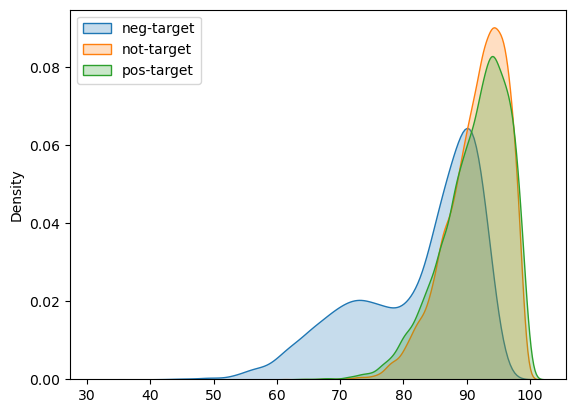

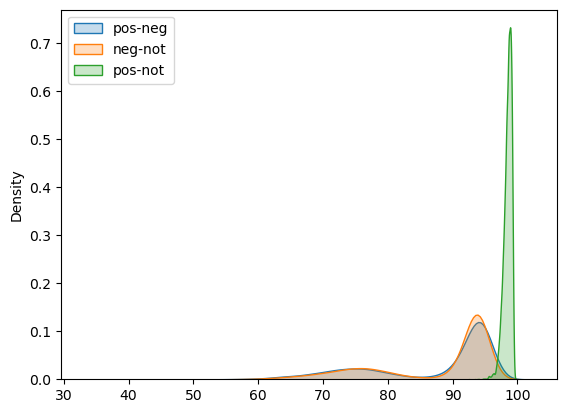

In [26]:
plt.figure()
sns.kdeplot(100*sim_neg_target, fill=True)
sns.kdeplot(100*sim_not_target, fill=True)
sns.kdeplot(100*sim_pos_target, fill=True)
plt.legend(["neg-target", "not-target", "pos-target"])

plt.figure()
sns.kdeplot(100*sim_pos_neg, fill=True)
sns.kdeplot(100*sim_neg_not, fill=True)
sns.kdeplot(100*sim_pos_not, fill=True)

plt.legend(["pos-neg","neg-not", "pos-not"])

plt.show()

In [56]:
def text_encoder(model, toks, not_embed=None, not_mask=False):
    x = model.token_embedding(toks).type(model.dtype)
    rows, cols = torch.where(toks == 783) # not_idx=783
    
    if not_embed is not None:
        for row, col in zip(rows, cols):
            x[row, [col], :] = not_embed
    
    x = x + model.positional_embedding.type(model.dtype)
    x = x.permute(1, 0, 2) 
    
    mask = torch.empty(toks.shape[0], model.context_length, model.context_length)
    mask.fill_(float("-inf"))
    mask.triu_(1)
    
    if not_mask:
        for row, col in zip(rows, cols):
            mask[row, col, col:] = 0.
            mask[row, col, :col] = float("-inf")
    
    mask = mask.repeat_interleave(model.transformer.resblocks[0].attn.num_heads, dim=0)
    mask = mask.to(dtype=x.dtype, device=x.device)
    
    
    for block in model.transformer.resblocks:
        y = block.ln_1(x)
        y = block.attn(y, y, y, need_weights=False, attn_mask=mask)[0]
        x = x + y
        y = block.mlp(block.ln_2(x))
        x = x + y
    
    x = x.permute(1, 0, 2)
    x = model.ln_final(x).type(model.dtype)
    x = x[torch.arange(x.shape[0]), toks.argmax(dim=-1)] @ model.text_projection
    
    texts_emb = F.normalize(x, dim=-1)
    
    return texts_emb




neg_embedding = NegationEmbedding(intializer=model.token_embedding.weight.data[[783]]).to(device)
optimizer = torch.optim.Adam(neg_embedding.parameters(), lr=5e-5)
criterion = nn.MSELoss()

for epoch in range(10):
    
    neg_embedding.train()
    cum_loss = 0.
    count = 0
    for i, (pos_word, neg_word, not_word) in tqdm(enumerate(trainloader), total=len(trainloader)):
        optimizer.zero_grad()

        pos_word = pos_word.to(device)
        neg_word = neg_word.to(device)
        not_word = not_word.to(device)

        # Compute texts embeddings
        pos_word_embed = text_encoder(model, pos_word, neg_embedding(), not_mask=True)
        neg_word_embed = text_encoder(model, neg_word, neg_embedding(), not_mask=True)
        not_word_embed = text_encoder(model, not_word, neg_embedding(), not_mask=True)

        # Compute the loss
        loss = model.logit_scale.exp() * criterion(not_word_embed, neg_word_embed)
        loss.backward()
        optimizer.step()
        cum_loss += loss.item()
        count += pos_word.shape[0]

    cum_loss /= count
    print(f"Epoch {epoch+1}: loss = {cum_loss:.4f}")
    
    save_file = {
        'epoch': epoch,
        'neg_embed_state_dict': neg_embedding.state_dict(),
        'loss': cum_loss,
    }
    torch.save(save_file, f'save/neg_embedv5.pth')

100%|██████████| 352/352 [01:46<00:00,  3.31it/s]


Epoch 1: loss = 0.0003


100%|██████████| 352/352 [01:48<00:00,  3.24it/s]


Epoch 2: loss = 0.0002


100%|██████████| 352/352 [01:56<00:00,  3.01it/s]


...

Epoch 8: loss = 0.0002


100%|██████████| 352/352 [01:52<00:00,  3.12it/s]


Epoch 9: loss = 0.0002


100%|██████████| 352/352 [01:48<00:00,  3.26it/s]

Epoch 10: loss = 0.0002


In [ ]:
"""neg_embedding = NegationEmbedding(intializer=model.token_embedding.weight.data[[783]]).to(device)
optimizer = torch.optim.Adam(neg_embedding.parameters(), lr=1e-5)
criterion = nn.MSELoss()

for epoch in range(5):
    
    neg_embedding.train()
    cum_loss = 0.
    count = 0
    for i, (word1, idx_type, word1_embed, word2_embed, _) in tqdm(enumerate(trainloader), total=len(trainloader)):
        optimizer.zero_grad()

        idx_type = idx_type.to(device)
        word1_embed = word1_embed.squeeze(dim=1).to(device)
        word2_embed = word2_embed.squeeze(dim=1).to(device)
        
        mask = torch.logical_or(idx_type == 2, idx_type == 3)

        word1_tokens = clip.tokenize(word1).to(device)
        x = model.token_embedding(clip.tokenize(word1).to(device))
        
        x1 = torch.cat([x[:,[0],:], neg_embedding().expand(x.shape[0], -1, -1), x[:, 1:-1,:]], dim=-2)
        x2 = torch.cat([x[:, 0:3 ,:], neg_embedding().expand(x.shape[0], -1, -1), x[:, 3:-1,:]], dim=-2)
        x = torch.zeros(x1.shape).to(device)
        x[mask] = x2[mask]
        x[~mask] = x1[~mask]

        ###################################################
        x = x + model.positional_embedding.type(model.dtype)
        x = x.permute(1, 0, 2)
        x = model.transformer(x)
        x = x.permute(1, 0, 2)
        x = model.ln_final(x).type(model.dtype)
        neg_word_embedding = x[torch.arange(x.shape[0]), word1_tokens.argmax(dim=-1)+1] @ model.text_projection
        neg_word_embedding = F.normalize(neg_word_embedding, dim=-1)
        ###################################################


        # Compute the loss
        loss = criterion(100. * neg_word_embedding, 100. * word2_embed)
        loss.backward()
        optimizer.step()
        cum_loss += loss.item()
        count += len(word1)

    cum_loss /= count
    print(f"Epoch {epoch+1}: loss = {cum_loss:.4f}")
    
    save_file = {
        'epoch': epoch,
        'neg_embed_state_dict': neg_embedding.state_dict(),
        'loss': cum_loss,
    }
    torch.save(save_file, f'save/neg_embedv3.pth')"""

100%|██████████| 352/352 [00:53<00:00,  6.62it/s]


Epoch 1: loss = 0.0410


100%|██████████| 352/352 [00:52<00:00,  6.70it/s]


Epoch 2: loss = 0.0362


100%|██████████| 352/352 [00:52<00:00,  6.70it/s]


Epoch 3: loss = 0.0348


100%|██████████| 352/352 [00:53<00:00,  6.54it/s]


Epoch 4: loss = 0.0336


100%|██████████| 352/352 [00:54<00:00,  6.41it/s]

Epoch 5: loss = 0.0327


## Additionals

In [ ]:
class CsvImageCaptionDataset(Dataset):
    def __init__(self, csv_file, transforms, sep=',', img_key='filepath', caption_key='captions'):
        self.df = pd.read_csv(csv_file, sep=sep)
        self.transforms = transforms
        self.img_key = img_key
        self.caption_key = caption_key

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx][self.img_key]
        images = self.transforms(Image.open(image_path))
        captions = eval(self.df.iloc[idx][self.caption_key])
        return images, captions

dataset = CsvImageCaptionDataset(csv_file='data/images/COCO_val_retrieval.csv', transforms=preprocess, img_key='filepath', caption_key='captions')

In [4]:
df = pd.read_csv('data/images/COCO_val_negated_retrieval_llama3.1_rephrased_affneg_true.csv')

In [15]:
eval(coco_data.iloc[0]['captions'])

['A man in a kitchen is making pizzas, but there is no chair in sight.',
 'A man in an apron stands in front of an oven with pans and bakeware nearby, without a chair in sight.',
 'No fork is present, but a baker is busy working in the kitchen, rolling out dough.',
 'A person stands by a stove in the kitchen, but a fork is noticeably absent.',
 "At the table, pies are being crafted, while a person stands by a wall adorned with pots and pans, and noticeably, there's no fork."]

In [46]:
data = pd.read_csv('/home/amirhossein.hajimohammadrezaie/ECOR_extended/Negation/WordnetAntonyms.csv')
data.head()

,Word,Count,POS,Antonyms
0,a la carte,10,adjective,table d'hote
1,a posteriori,12,adjective,a priori
2,a posteriori,12,adverb,a priori
3,a priori,8,adjective,a posteriori
4,a priori,8,adverb,a posteriori


In [47]:
@torch.no_grad()
def compute_embeddings(model, texts):

    text_inputs = clip.tokenize(texts).to(device)
    block_size = 50
    blocks_num = np.ceil(len(text_inputs) / block_size)

    texts_embed = []
    for i in range(int(blocks_num)):
        start = i * block_size
        end = min((i + 1) * block_size, len(text_inputs))
        text_inputs_block = text_inputs[start:end]
        temp_embed = model.encode_text(text_inputs_block)
        temp_embed /= temp_embed.norm(dim=-1, keepdim=True)
        texts_embed.append(temp_embed)

    texts_embed = torch.cat(texts_embed, dim=0)

    return texts_embed

In [48]:
texts = data['Word'].apply(lambda x: f"a photo of {x}").tolist()
neg_texts = data['Antonyms'].apply(lambda x: f"a photo of {x}").tolist()

texts_embed = compute_embeddings(model, texts)
negs_embed = compute_embeddings(model, neg_texts)

texts_embed = torch.stack([texts_embed, negs_embed], dim=1)

In [49]:
texts2 = data['Word'].apply(lambda x: f"a photo of {x}").tolist()
neg2_texts = data['Word'].apply(lambda x: f"not a photo of {x}").tolist()

texts2_embed = compute_embeddings(model, texts2)
negs2_embed = compute_embeddings(model, neg2_texts)

neg_texts_embed = torch.stack([texts2_embed, negs2_embed], dim=1)

In [ ]:
with torch.no_grad():
    res = torch.linalg.lstsq(neg_texts_embed[:, 1, :], texts_embed[:, 1, :])
    W = res.solution

In [62]:
with torch.no_grad():
    dot = torch.sum(texts_embed[:, 1, :] * (neg_texts_embed[:, 1, :] @ W), dim=-1)

In [ ]:
dot = (texts_embed[:, 0, :] * texts_embed[:, 1, :]).sum(dim=-1)
print(f"{dot.mean()}")
print(f"{dot.std()}")

0.89013671875
0.055938720703125


In [41]:
dot = (texts_embed[:, 0, :] * neg_texts_embed[:, 1, :]).sum(dim=-1)
print(f"{dot.mean()}")
print(f"{dot.std()}")

0.96435546875
0.011749267578125


In [208]:
df = pd.read_csv('data/images/COCO_val_negated_retrieval_llama3.1_rephrased_affneg_true.csv', sep=',')

In [214]:
df2 = pd.read_csv('data/images/COCO_val_retrieval.csv', sep=',')

In [216]:
eval(df2.iloc[0]['captions'])

['A man is in a kitchen making pizzas.',
 'Man in apron standing on front of oven with pans and bakeware',
 'A baker is working in the kitchen rolling dough.',
 'A person standing by a stove in a kitchen.',
 'A table with pies being made and a person standing near a wall with pots and pans hanging on the wall.']

In [213]:
df

,positive_objects,negative_objects,filepath,image_id,captions
0,"['person', 'bottle', 'cup', 'knife', 'spoon', ...","['chair', 'fork', 'car']",data/coco/images/val2017/000000397133.jpg,397133,"['A man in a kitchen is making pizzas, but the..."
1,"['banana', 'orange', 'chair', 'potted plant', ...","['person', 'cup', 'bottle']",data/coco/images/val2017/000000037777.jpg,37777,"['No cup can be seen; however, the dining tabl..."
2,"['person', 'traffic light', 'umbrella', 'handb...","['chair', 'car', 'dining table']",data/coco/images/val2017/000000252219.jpg,252219,['A person with a shopping cart is on a city s...
3,"['person', 'bicycle', 'skateboard']","['car', 'chair', 'handbag']",data/coco/images/val2017/000000087038.jpg,87038,"['No car is present in the image, where a pers..."
4,"['bicycle', 'car', 'truck', 'traffic light']","['person', 'bus', 'handbag']",data/coco/images/val2017/000000174482.jpg,174482,"['No bus is in the image, but a blue bike is p..."
...,...,...,...,...,...
4995,"['potted plant', 'book', 'vase']","['chair', 'person', 'dining table']",data/coco/images/val2017/000000512403.jpg,512403,"['No chair is in view, but a vase of feathers ..."
4996,"['person', 'remote', 'cell phone']","['chair', 'car', 'handbag']",data/coco/images/val2017/000000168974.jpg,168974,['A little baby sits on the floor with a cell ...
4997,"['person', 'bottle', 'knife', 'spoon', 'bowl',...","['dining table', 'chair', 'cup']",data/coco/images/val2017/000000552775.jpg,552775,"['Absent from the image is a chair, but notabl..."
4998,"['person', 'knife', 'cake', 'dining table']","['chair', 'cup', 'bottle']",data/coco/images/val2017/000000394940.jpg,394940,"['No bottle is visible in this scene, where a ..."


In [ ]:
class CsvImageCaptionDataset(Dataset):
    def __init__(self, csv_file, transforms, sep=',', img_key='filepath', caption_key='captions'):
        self.df = pd.read_csv(csv_file, sep=sep)
        self.transforms = transforms
        self.img_key = img_key
        self.caption_key = caption_key

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx][self.img_key]
        images = self.transforms(Image.open(image_path))
        captions = eval(self.df.iloc[idx][self.caption_key])
        return images, captions

dataset = CsvImageCaptionDataset(csv_file='data/images/COCO_val_retrieval.csv', transforms=preprocess, img_key='filepath', caption_key='captions')